In [1]:
import numpy as np
import yaml

from copy import deepcopy

from witch.fitter import load_config
from witch.cfg_loader import load_cfg

import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

In [7]:
#Load in the data and models.
#TODO: right now this does some busy work loading the data and e.g. computing the noise map
#that it probably doesn't need to do if all you want to do is look at the model. Still it
#doesn't take very long and it's useful in other circumstances so I'm going to leave it in for the timebeing.

path = "/home/jorlo/dev/minkasi_jax/unit_tests/RXJ1347_a10.yaml"
cfg = load_config({}, path)
datasets, outdir, dset_names, metamodel = load_cfg(cfg)


deleted  0  bad files.
WARNING - calinfo information not found in fits file header - to track JytoK etc you may need to reprocess the fits files using mustangidl > revision 932
ndata and ndet are  72 23691 72  on  /mnt/welch/MUSTANG/M2-TODs/RXJ1347/mustang2/Signal_TOD-AGBT16A_473_02-s134.fits with lims  206.79301 206.94154 -11.834224 -11.675019
truncating from  23691  to  23626
WARNING - calinfo information not found in fits file header - to track JytoK etc you may need to reprocess the fits files using mustangidl > revision 932
ndata and ndet are  76 9219 76  on  /mnt/welch/MUSTANG/M2-TODs/RXJ1347/mustang2/Signal_TOD-AGBT16A_473_02-s135.fits with lims  206.79442 206.92502 -11.828844 -11.675086
truncating from  9219  to  9217
WARNING - calinfo information not found in fits file header - to track JytoK etc you may need to reprocess the fits files using mustangidl > revision 932
ndata and ndet are  166 23691 166  on  /mnt/welch/MUSTANG/M2-TODs/RXJ1347/mustang2/Signal_TOD-AGBT17A_358_03-s

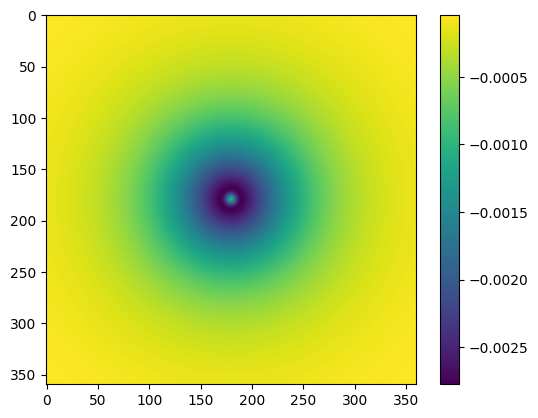

In [8]:
#To plot the full model on a given dataset, we use
#metamodel.model_grid(i), where i is the dataset of interest
#Plotting multiple datasets at the same time is in general non-sensical
#i.e. plotting x-ray and M2 simultaneously. However it can sometimes be 
#well defined (i.e. ACT+M2). In that case, you have to manually
# 1) get the maps in the same units 
# 2) get the maps in the same pixelation, probably by interpolation
#This is a pretty niche application so no example is given here
plt.imshow(metamodel.model_grid(0))
plt.colorbar()


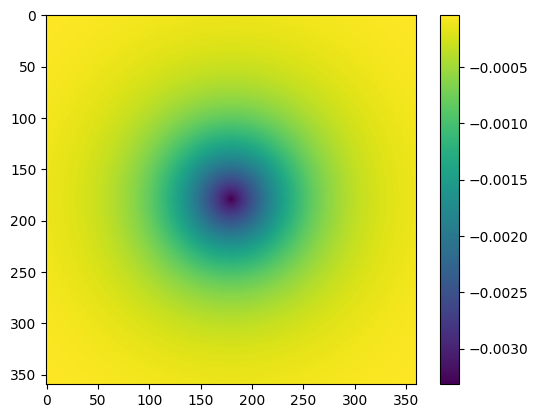

In [6]:
#If you want to only look at one component of the model, you can do the following:

plt.imshow(metamodel.models[0].model*metamodel.datasets[0].metadata[0].prefactor)
plt.colorbar()